Neste desafio, você aplicará conceitos de Visão Computacional para criar uma aplicação prática de Reconhecimento Facial voltada ao controle de acesso, utilizando a biblioteca DeepFace em conjunto com o OpenCV e o Matplotlib.

Para tanto, você deverá:

- Realizar as importações e configurações necessárias das bibliotecas.
- Carregar uma imagem e padronizar o espaço de cor (BGR → RGB).
- Aplicar o modelo pré-treinado da DeepFace para comparar imagem de teste com um banco de imagens autorizadas.
- Exibir o resultado indicando se o rosto é AUTORIZADO ou NÃO AUTORIZADO.
Destacar o resultado visualmente na imagem, desenhando uma moldura colorida com base na classificação.

Nesta atividade, você utilizará um ambiente de programação Python com notebooks (como o Google Colab). O desafio consiste em completar trechos de códigos, executar e, principalmente, compreender o passo a passo detalhado em cada célula. Siga as orientações, execute os códigos, analise os resultados e qualquer dúvida procure seu professor.

O seu notebook e a sua análise final devem, no mínimo, conter:

1. Importar as bibliotecas DeepFace, OpenCV e Matplotlib.
2. Carregar uma imagem de teste e garantir sua exibição correta (conversão BGR→RGB).
3. Comparar a imagem de teste com o diretório “autorizados/” utilizando o método DeepFace.find().
4. Classificar o resultado como “AUTORIZADO” ou “NÃO AUTORIZADO”.
5. Exibir a imagem final com uma moldura verde ou vermelha, conforme o resultado obtido.

Baixando os arquivos necessários para a análise com OpenCV e DeepFace

Serão utilizadas fotos de artistas de Hollywood, de forma que uma imagem estará no banco de dados autorizado e a outra imagem será utilizada para testes de acesso. Além disso, outras duas fotos de artistas que não pertencem ao banco de usuários autorizados também serão utilizadas para testes em caso negativo.

In [127]:
# USUÁRIOS AUTORIZADOS
# Imagens do ator Brad Pitt do WikiPedia: https://pt.wikipedia.org/wiki/Brad_Pitt
# Imagens do ator Keanu Reeves do WikiPedia: https://pt.wikipedia.org/wiki/Keanu_Reeves
# Imagens da atriz Angelina Jolie do WikiPedia: https://pt.wikipedia.org/wiki/Angelina_Jolie

!wget --no-check-certificate \
  https://upload.wikimedia.org/wikipedia/commons/thumb/9/90/Brad_Pitt-69858.jpg/500px-Brad_Pitt-69858.jpg \
  -O brad.jpg
!wget --no-check-certificate \
  https://upload.wikimedia.org/wikipedia/commons/thumb/8/85/War_Machine_Japan_Premiere_Red_Carpet-_Brad_Pitt_%2838338138066%29_%28cropped%29.jpg/960px-War_Machine_Japan_Premiere_Red_Carpet-_Brad_Pitt_%2838338138066%29_%28cropped%29.jpg \
  -O brad_alt.jpg

!wget --no-check-certificate \
  https://upload.wikimedia.org/wikipedia/commons/thumb/b/b4/Keanu_Reeves_at_TIFF_2025_02_%28Cropped%29.jpg/960px-Keanu_Reeves_at_TIFF_2025_02_%28Cropped%29.jpg \
  -O keanu.jpg
!wget --no-check-certificate \
  https://upload.wikimedia.org/wikipedia/commons/thumb/3/33/Reuni%C3%A3o_com_o_ator_norte-americano_Keanu_Reeves_%2846806576944%29_%28cropped%29.jpg/960px-Reuni%C3%A3o_com_o_ator_norte-americano_Keanu_Reeves_%2846806576944%29_%28cropped%29.jpg \
  -O keanu_alt.jpg

!wget --no-check-certificate \
  https://upload.wikimedia.org/wikipedia/commons/thumb/b/b2/Angelina_Jolie_by_Gage_Skidmore_3.jpg/960px-Angelina_Jolie_by_Gage_Skidmore_3.jpg \
  -O angelina.jpg
!wget --no-check-certificate \
  https://upload.wikimedia.org/wikipedia/commons/9/90/Angelina_Jolie.jpg \
  -O angelina_alt.jpg

# USUÁRIOS NÃO AUTORIZADOS
# Imagem do ator Morgan Freeman do WikiPedia: https://pt.wikipedia.org/wiki/Morgan_Freeman
# Imagem da atriz Scarlet Johansson do WikiPedia: https://pt.wikipedia.org/wiki/Scarlett_Johansson

!wget --no-check-certificate \
  https://upload.wikimedia.org/wikipedia/commons/thumb/4/42/Morgan_Freeman_at_The_Pentagon_on_2_August_2023_-_230802-D-PM193-3363_%28cropped%29.jpg/960px-Morgan_Freeman_at_The_Pentagon_on_2_August_2023_-_230802-D-PM193-3363_%28cropped%29.jpg \
  -O morgan.jpg
!wget --no-check-certificate \
  https://upload.wikimedia.org/wikipedia/commons/thumb/5/5e/Goldene_Kamera_2012_-_Scarlett_Johansson_3_%28cropped%29.JPG/960px-Goldene_Kamera_2012_-_Scarlett_Johansson_3_%28cropped%29.JPG \
  -O scarlet.jpg

# Cascade Frontal Face do GitHub: https://github.com/computationalcore/introduction-to-opencv

!wget --no-check-certificate \
  https://raw.githubusercontent.com/computationalcore/introduction-to-opencv/master/assets/haarcascade_frontalface_default.xml \
  -O haarcascade_frontalface_default.xml

--2026-04-01 00:29:53--  https://upload.wikimedia.org/wikipedia/commons/thumb/9/90/Brad_Pitt-69858.jpg/500px-Brad_Pitt-69858.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 208.80.154.240, 2620:0:861:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|208.80.154.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64569 (63K) [image/jpeg]
Saving to: ‘brad.jpg’

brad.jpg            100%[===================>]  63.06K  --.-KB/s    in 0.02s   

2026-04-01 00:29:53 (2.72 MB/s) - ‘brad.jpg’ saved [64569/64569]

--2026-04-01 00:29:53--  https://upload.wikimedia.org/wikipedia/commons/thumb/8/85/War_Machine_Japan_Premiere_Red_Carpet-_Brad_Pitt_%2838338138066%29_%28cropped%29.jpg/960px-War_Machine_Japan_Premiere_Red_Carpet-_Brad_Pitt_%2838338138066%29_%28cropped%29.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 208.80.154.240, 2620:0:861:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|208.80.154.240|:443... c

Como a biblioteca DeepFace não faz parte do pacote de bibliotecas padrão do Google Colab, é necessário instalá-la manualmente

In [ ]:
!pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.7 MB/s eta 0:00:00


Importações das bibliotecas necessárias
- OpenCV
- DeppFace
- Maatplotlib
- Pandas
- Random
- OS

In [ ]:
import matplotlib.pyplot as plt
from deepface import DeepFace
import pandas as pd
import random
import cv2
import os

print("\033[32mImportações realizadas com sucesso!\033[m")

26-04-01 00:05:35 - Directory /root/.deepface has been created
26-04-01 00:05:35 - Directory /root/.deepface/weights has been created
Importações realizadas com sucesso!


Sorteando e garantindo a exibição correta das imagens, convertendo de BGR -> RGB


Imagem selecionada: keanu.jpg


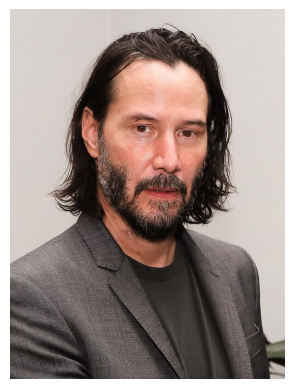

In [159]:
# Sorteando uma imagem do banco de imagens de testes autorizados
rand_image = random.choice(os.listdir("testes"))
print("Imagem selecionada:", rand_image)
image = cv2.imread(f"testes/{rand_image}")

# Padronizando a exibição da imagem
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Exibição da imagem para fins de comparação
plt.imshow(image_rgb)
plt.axis(False)
plt.show()

Verificando com DeepFace se o usuário selecionado é ou não autorizado

In [160]:
# Analise da imagem com as demais do banco de dados
db = "autorizados/"
verificador = DeepFace.find(img_path = image, db_path = db)

# Retorno da análise
if verificador[0].empty:
    print("\033[31mNÃO AUTORIZADO.\033[m")
else:
    print("\033[32mAUTORIZADO\033[m")

26-04-01 00:36:51 - Searching [[[209 213 218]
  [209 213 218]
  [209 213 218]
  ...
  [215 219 224]
  [215 219 224]
  [215 219 224]]

 [[209 213 218]
  [209 213 218]
  [209 213 218]
  ...
  [215 219 224]
  [215 219 224]
  [215 219 224]]

 [[209 213 218]
  [209 213 218]
  [209 213 218]
  ...
  [215 219 224]
  [215 219 224]
  [215 219 224]]

 ...

 [[ 31  34  39]
  [  0   0   4]
  [  0   0   4]
  ...
  [175 182 191]
  [173 180 189]
  [170 177 186]]

 [[ 24  27  32]
  [ 59  62  67]
  [ 17  20  25]
  ...
  [175 182 191]
  [173 180 189]
  [170 177 186]]

 [[ 52  55  59]
  [ 51  54  58]
  [ 25  28  32]
  ...
  [177 184 193]
  [176 183 192]
  [173 180 189]]] in 3 length datastore
26-04-01 00:36:52 - find function duration 2.4217824935913086 seconds
AUTORIZADO


Exibindo a imagem analisada realçada com um retângulo verde ou vermelho se foi, respectivamente, autorizada ou não autorizada

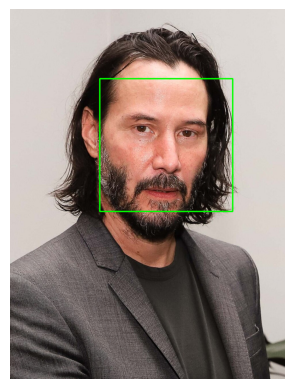

In [161]:
# Carregando o classificador Cascade
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# Utilizando a imagem em escala de cinza para detectar a posição relativa do rosto
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
detected_face = face_cascade.detectMultiScale(image_gray, scaleFactor=1.3, minNeighbors=5)

# Verificando a face detectada
for (start_x, start_y, width, height) in detected_face:
  end_x = start_x + width
  end_y = start_y + height

  if verificador[0].empty:
    # Desenha um retângulo vermelho ao redor do rosto detectado
    cv2.rectangle(
        img = image,
        pt1 = (start_x, start_y),
        pt2 = (end_x, end_y),
        color = [0, 0, 255],
        thickness = 4
    )
  else:
    # Desenha um retângulo verde ao redor do rosto detectado
    cv2.rectangle(
        img = image,
        pt1 = (start_x, start_y),
        pt2 = (end_x, end_y),
        color = [0, 255, 0],
        thickness = 4
    )

# Convertendo as cores da imagem de BGR para RGB e exibindo-a
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Imagem com rosto detectado
plt.imshow(image_rgb)
plt.axis("off")
plt.show()